# Import libraries

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
from tqdm import tqdm


# Load and visualize MNIST data

In [3]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.Grayscale(num_output_channels=3),  # convert 1 → 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [4]:
# Load training and test datasets
train_dataset = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="../data", train=False, transform=transform)

In [5]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

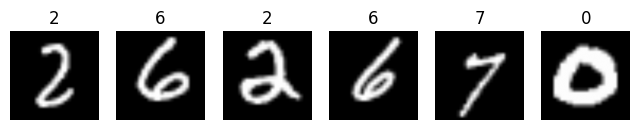

In [6]:
# Visualize some samples
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(8, 3))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(example_targets[i].item())
    plt.axis('off')
plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
model = torchvision.models.resnet18(weights=None)
model.fc = torch.nn.Linear(in_features=512, out_features=10)

# Clear GPU memory cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Move model to device
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [10]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for images, labels in progress_bar:
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Training step
        optimizer.zero_grad()
        outputs = model(images)

        # Compute loss and backpropagate
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Update weights
        optimizer.step()

        # Update running loss
        running_loss += loss.item()

        current_loss = running_loss / (len(progress_bar) + 1e-8)
        progress_bar.set_postfix(loss=current_loss)

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}]  Average Loss: {avg_loss:.4f}")

Epoch 1/3:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch [1/3]  Average Loss: 0.1172


Epoch [2/3]  Average Loss: 0.0527


Epoch [3/3]  Average Loss: 0.0401


# Evaluate the model

In [11]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():  # ปิดการคำนวณ gradient เพื่อประหยัด GPU
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)  # [batch, 10]
        _, preds = torch.max(outputs, 1)  # ดึง class ที่มีค่า logit สูงสุด
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


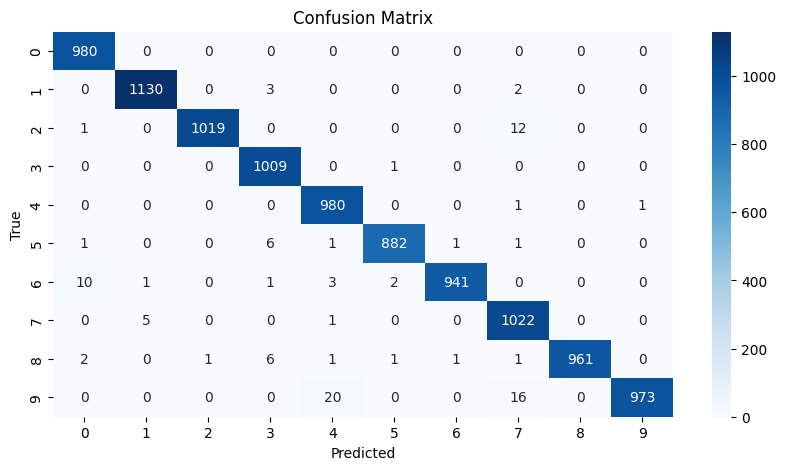

In [12]:
# Plot confusion matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [13]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))


Classification Report:

              precision    recall  f1-score   support

           0     0.9859    1.0000    0.9929       980
           1     0.9947    0.9956    0.9952      1135
           2     0.9990    0.9874    0.9932      1032
           3     0.9844    0.9990    0.9916      1010
           4     0.9742    0.9980    0.9859       982
           5     0.9955    0.9888    0.9921       892
           6     0.9979    0.9823    0.9900       958
           7     0.9687    0.9942    0.9813      1028
           8     1.0000    0.9867    0.9933       974
           9     0.9990    0.9643    0.9813      1009

    accuracy                         0.9897     10000
   macro avg     0.9899    0.9896    0.9897     10000
weighted avg     0.9899    0.9897    0.9897     10000



# Visual OCR results

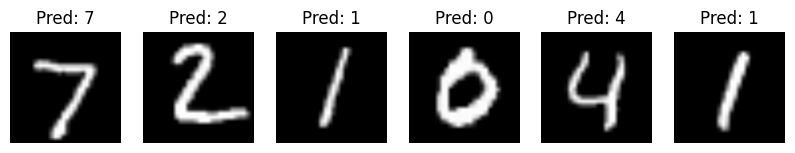

In [14]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)

_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10, 3))

images = images.cpu()
preds = preds.cpu()

for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Pred: {preds[i].item()}")
    plt.axis('off')
plt.show()


# Save Model

In [ ]:
torch.save(model.state_dict(), "../checkpoints/mnist_resnet18_epoch_3.pth")

# Inference on new images

In [32]:
import os

In [33]:
path = "../checkpoints/mnist_resnet18_epoch_3.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
def load_model(path, device=device):
    # create architecture
    model = torchvision.models.resnet18(weights=None)
    model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=10)

    # load weights (map to device)
    if os.path.exists(path):
        state = torch.load(path, map_location=device)
        model.load_state_dict(state)
    else:
        print(f"Warning: model weights not found at {path}. Using random weights.")
    
    model.to(device)
    model.eval()
    return model

In [35]:
model = load_model(path, device)

In [36]:
# Preprocessing (same as training)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.Grayscale(num_output_channels=3),  # convert 1 → 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [37]:
test_images  = datasets.MNIST(root="../data", train=False, download=True)

(28, 28)


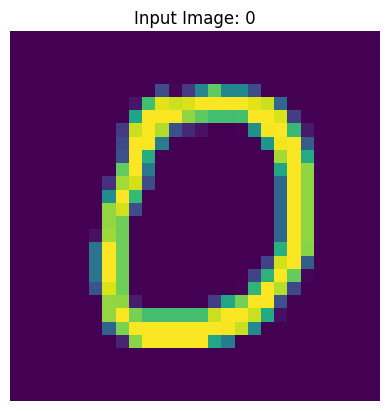

In [38]:
image_pil, label = test_images[10]  # ดึงภาพตัวแรก

print(image_pil.size)  # ตรวจสอบขนาด tensor

plt.title(f"Input Image: {label}")
plt.imshow(image_pil)
plt.axis('off')
plt.show()

In [39]:
# MNIST เป็น grayscale (1 channel) → convert เป็น RGB (3 channels)
# image_pil = transforms.ToPILImage()(image_tensor)  # grayscale
# image_rgb = image_pil.convert("RGB")  # now 3-channel
image_rgb = image_pil

In [40]:
image_rgb.size

(28, 28)

In [41]:
input_tensor = preprocess(image_rgb).unsqueeze(0).to(device)  # shape [1, C, H, W]
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [42]:
# 5) inference
with torch.no_grad():
    outputs = model(input_tensor)  # logits [1, 10]
    probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy().tolist()[0]
    pred_class = int(torch.argmax(outputs, dim=1).cpu().item())

print(f"Predicted Class: {pred_class}")

Predicted Class: 0
